# QTQ Measurement v6 — basis-adaptive pipeline

v5 showed that the right basis depends on the state class — TFIM is most concentrated in
DCT (k* = 27), Heisenberg ties WHT/Identity (k* = 56), Clifford prefers WHT (k* = 542),
and random MPS at any chi stays in the bulk in every basis. v6 actually exploits this:
the encoder picks the basis per vector, sends a 2-bit basis tag, and the decoder reads it
back to invert correctly.

Three strategies compared at 3/3 bits, top-k k=8, full pipeline:

- **WHT-only (baseline):** the v3 default. Replays the existing pipeline; numbers should match
  results_v3.csv to within QJL-seed noise.
- **k\*-adaptive:** encoder picks the basis with the smallest k\*(0.9). Realistic — the encoder
  computes k\* in three bases (cheap, three transforms + sorts), picks one, runs the pipeline.
  Pays 2 bits for the basis tag.
- **oracle-adaptive:** encoder runs the full pipeline in every basis and picks the one with the
  highest decoded fidelity. This is an upper bound — not realistic in production but tells us
  how good a predictor k\* is for the actual quantity we care about.

## Hypotheses

1. **TFIM gains the most.** v5 said DCT-TFIM has k\* = 27 vs WHT 42; the smoke test already
   shows DCT-TFIM gives F = 0.9943 vs WHT-TFIM F = 0.988 at 3/3. Predict: k\*-adaptive lifts
   TFIM by ~0.5–1.0 percentage points; oracle matches the k\*-adaptive number.
2. **Heisenberg ties.** WHT and Identity have the same k\* = 56 (DCT worse). Predict: little
   change vs WHT baseline; adaptive may pick either WHT or Identity.
3. **Bulk states unchanged.** Haar / random MPS at any chi: no basis has small k\*, so the
   pipeline can't extract more fidelity. Adaptive picks may flicker between bases but
   fidelity stays at the ~0.955 floor (or drops by 2 bits / 7488 bits ~ 0% of the ratio).
4. **Clifford may *lose*.** WHT-Clifford has F = 1.0 because of the magnitude degeneracy
   property in the WHT basis. v5 showed Clifford k\* is largest in identity; if k\*-adaptive
   picks WHT (smallest k\*), it should hold F = 1.0. But there's a subtlety — Clifford WHT
   has k\* = 542 (larger than e.g. MPS-chi=2's 274 in identity), so for some Clifford samples
   the k\*-adaptive may misroute. Worth watching.
5. **k\* matches oracle.** If k\*(0.9) is a good encoder-side proxy for fidelity, the
   k\*-adaptive and oracle strategies should give the same fidelity (within sampling noise).
   If oracle is much better than k\*, the predictor is wrong somewhere.


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pipeline as pl
import states

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

ALL_STATE_NAMES = ['haar', 'tfim', 'mps', 'heisenberg', 'mps_chi2', 'mps_chi4', 'clifford']
STATE_LABELS = {
    'haar': 'Haar-random',
    'tfim': 'TFIM ground state',
    'mps': 'Random MPS (χ=16)',
    'heisenberg': 'Heisenberg ground state',
    'mps_chi2': 'Random MPS (χ=2)',
    'mps_chi4': 'Random MPS (χ=4)',
    'clifford': 'Random Clifford state',
}
STRATEGY_LABELS = {
    'wht_only': 'WHT-only (baseline)',
    'kstar': 'k*-adaptive (realistic)',
    'oracle': 'Oracle (upper bound)',
}
STRATEGY_COLORS = {'wht_only': '#5b8c5a', 'kstar': '#3f6fb0', 'oracle': '#b07a3f'}
N_SAMPLES = 20

print('imports ok')


imports ok


In [2]:
# Run all three strategies on every state class.
records = []
basis_picks = []  # which basis did each adaptive call pick
t0 = time.time()
for state_name in ALL_STATE_NAMES:
    gen = states.STATE_GENERATORS[state_name]
    state_t0 = time.time()
    for sample_idx in range(N_SAMPLES):
        psi = gen(seed=sample_idx)
        qjl_seed = 60_000 * (1 + ALL_STATE_NAMES.index(state_name)) + sample_idx

        # Strategy 1: WHT-only (re-run for fair seed alignment).
        p_wht = pl.compress(psi, 'full', bits_mag=3, bits_phase=3,
                             mag_quantizer='topk', basis='wht', qjl_seed=qjl_seed)
        f_wht = pl.fidelity(psi, pl.decompress(p_wht))
        records.append({'state_class': state_name, 'strategy': 'wht_only',
                         'sample_idx': sample_idx, 'fidelity': f_wht,
                         'compression_ratio': pl.compression_ratio(p_wht),
                         'basis': 'wht'})

        # Strategy 2: k*-adaptive.
        p_k = pl.compress_adaptive_kstar(psi, bits_mag=3, bits_phase=3,
                                          mag_quantizer='topk', qjl_seed=qjl_seed)
        f_k = pl.fidelity(psi, pl.decompress(p_k))
        records.append({'state_class': state_name, 'strategy': 'kstar',
                         'sample_idx': sample_idx, 'fidelity': f_k,
                         'compression_ratio': pl.compression_ratio(p_k),
                         'basis': p_k.basis})
        basis_picks.append({'state_class': state_name, 'strategy': 'kstar',
                             'sample_idx': sample_idx, 'basis': p_k.basis})

        # Strategy 3: oracle-adaptive.
        p_o = pl.compress_adaptive_oracle(psi, bits_mag=3, bits_phase=3,
                                           mag_quantizer='topk', qjl_seed=qjl_seed)
        f_o = pl.fidelity(psi, pl.decompress(p_o))
        records.append({'state_class': state_name, 'strategy': 'oracle',
                         'sample_idx': sample_idx, 'fidelity': f_o,
                         'compression_ratio': pl.compression_ratio(p_o),
                         'basis': p_o.basis})
        basis_picks.append({'state_class': state_name, 'strategy': 'oracle',
                             'sample_idx': sample_idx, 'basis': p_o.basis})
    print(f'v6 {state_name:>11}: {time.time() - state_t0:6.1f}s')

df = pd.DataFrame(records)
picks = pd.DataFrame(basis_picks)
df.to_csv('results_v6.csv', index=False)
picks.to_csv('results_v6_basis_picks.csv', index=False)
print(f'\nTotal: {len(df)} rows, {time.time() - t0:.1f}s -> results_v6.csv')


v6        haar:    8.5s


v6        tfim:    8.5s


v6         mps:    8.4s


v6  heisenberg:    8.4s


v6    mps_chi2:    8.4s


v6    mps_chi4:    8.4s


v6    clifford:    8.3s

Total: 420 rows, 58.9s -> results_v6.csv


In [3]:
# Aggregate fidelity per (state, strategy).
agg = (df.groupby(['state_class', 'strategy'])
          .agg(fid_mean=('fidelity', 'mean'),
               fid_std=('fidelity', 'std'),
               ratio=('compression_ratio', 'mean'))
          .reset_index())
fid_pivot = agg.pivot(index='state_class', columns='strategy', values='fid_mean').reindex(ALL_STATE_NAMES)
fid_pivot = fid_pivot[['wht_only', 'kstar', 'oracle']]
print('Mean fidelity per (state, strategy), n=20:')
print(fid_pivot.round(4).to_string())

# Per-state lift table.
lifts = pd.DataFrame({
    'state_class': ALL_STATE_NAMES,
    'wht_F': fid_pivot['wht_only'].values,
    'kstar_F': fid_pivot['kstar'].values,
    'oracle_F': fid_pivot['oracle'].values,
})
lifts['kstar_lift_pp'] = (lifts['kstar_F'] - lifts['wht_F']) * 100
lifts['oracle_lift_pp'] = (lifts['oracle_F'] - lifts['wht_F']) * 100
lifts['kstar_vs_oracle_gap_pp'] = (lifts['oracle_F'] - lifts['kstar_F']) * 100
print()
print('Per-state lift over WHT-only baseline (in percentage points of F):')
print(lifts[['state_class', 'wht_F', 'kstar_F', 'oracle_F',
              'kstar_lift_pp', 'oracle_lift_pp', 'kstar_vs_oracle_gap_pp']].to_string(index=False))


Mean fidelity per (state, strategy), n=20:
strategy     wht_only   kstar  oracle
state_class                          
haar           0.9580  0.9582  0.9593
tfim           0.9890  0.9947  0.9947
mps            0.9570  0.9563  0.9584
heisenberg     0.9804  0.9804  0.9909
mps_chi2       0.9550  0.9547  0.9574
mps_chi4       0.9545  0.9532  0.9574
clifford       1.0000  0.9934  1.0000

Per-state lift over WHT-only baseline (in percentage points of F):
state_class    wht_F  kstar_F  oracle_F  kstar_lift_pp  oracle_lift_pp  kstar_vs_oracle_gap_pp
       haar 0.957978 0.958188  0.959322       0.020989    1.344214e-01                0.113433
       tfim 0.988979 0.994672  0.994672       0.569299    5.692990e-01                0.000000
        mps 0.957030 0.956321  0.958419      -0.070903    1.388350e-01                0.209738
 heisenberg 0.980422 0.980422  0.990918       0.000000    1.049523e+00                1.049523
   mps_chi2 0.954979 0.954677  0.957377      -0.030273    2.397456e-01  

In [4]:
# Basis pick distribution per state class.
print('Basis-pick distribution by state class (k*-adaptive vs oracle, n=20):')
for s in ALL_STATE_NAMES:
    sub_k = picks[(picks['state_class'] == s) & (picks['strategy'] == 'kstar')]
    sub_o = picks[(picks['state_class'] == s) & (picks['strategy'] == 'oracle')]
    k_counts = sub_k['basis'].value_counts().to_dict()
    o_counts = sub_o['basis'].value_counts().to_dict()
    print(f'  {STATE_LABELS[s]:>26}:  k*-pick = {k_counts}   oracle-pick = {o_counts}')


Basis-pick distribution by state class (k*-adaptive vs oracle, n=20):
                 Haar-random:  k*-pick = {'identity': 10, 'wht': 6, 'dct': 4}   oracle-pick = {'identity': 12, 'wht': 4, 'dct': 4}
           TFIM ground state:  k*-pick = {'dct': 20}   oracle-pick = {'dct': 20}
           Random MPS (χ=16):  k*-pick = {'identity': 10, 'wht': 9, 'dct': 1}   oracle-pick = {'wht': 8, 'dct': 8, 'identity': 4}
     Heisenberg ground state:  k*-pick = {'wht': 20}   oracle-pick = {'dct': 20}
            Random MPS (χ=2):  k*-pick = {'identity': 12, 'wht': 6, 'dct': 2}   oracle-pick = {'identity': 11, 'wht': 6, 'dct': 3}
            Random MPS (χ=4):  k*-pick = {'wht': 14, 'identity': 6}   oracle-pick = {'dct': 14, 'wht': 3, 'identity': 3}
       Random Clifford state:  k*-pick = {'wht': 14, 'dct': 3, 'identity': 3}   oracle-pick = {'wht': 17, 'identity': 3}


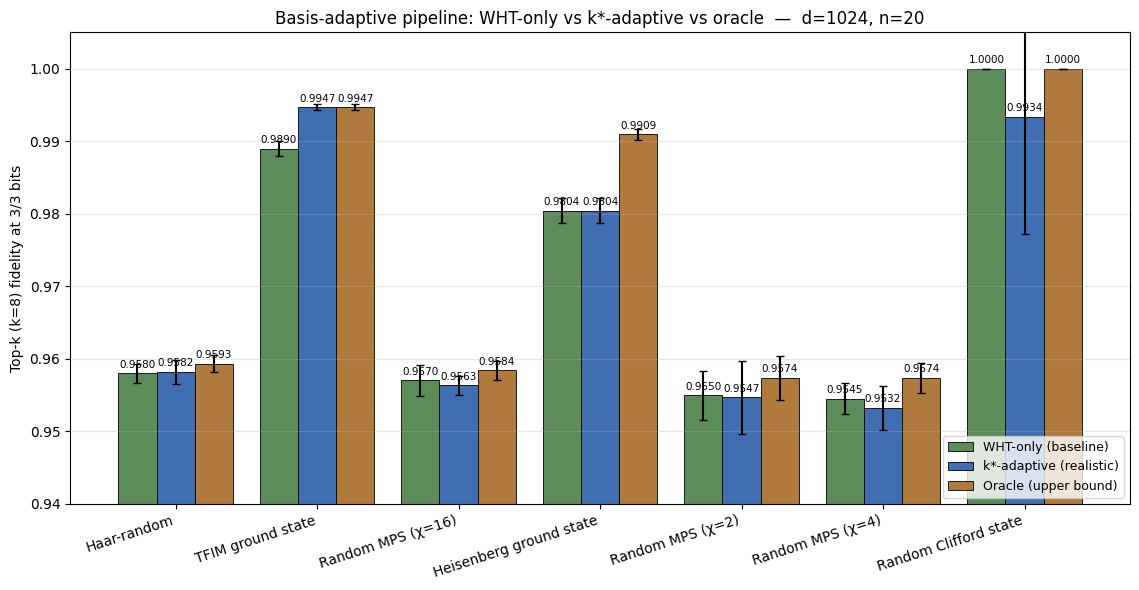

saved figures\v6_adaptive_pipeline.png


In [5]:
# Grouped bar plot: 3 strategies per state class.
fig, ax = plt.subplots(figsize=(11.5, 6))
x = np.arange(len(ALL_STATE_NAMES))
width = 0.27

for i, strat in enumerate(['wht_only', 'kstar', 'oracle']):
    means = fid_pivot[strat].values
    stds = (df[df['strategy'] == strat]
              .groupby('state_class')['fidelity'].std()
              .reindex(ALL_STATE_NAMES).values)
    offset = (i - 1) * width
    bars = ax.bar(x + offset, means, width, yerr=stds, capsize=3,
                   color=STRATEGY_COLORS[strat], edgecolor='black', linewidth=0.6,
                   label=STRATEGY_LABELS[strat])
    for bar, m in zip(bars, means):
        ax.annotate(f'{m:.4f}',
                     (bar.get_x() + bar.get_width()/2, m),
                     textcoords='offset points', xytext=(0, 4),
                     ha='center', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels([STATE_LABELS[s] for s in ALL_STATE_NAMES], rotation=18, ha='right')
ax.set_ylabel('Top-k (k=8) fidelity at 3/3 bits')
ax.set_title('Basis-adaptive pipeline: WHT-only vs k*-adaptive vs oracle  —  d=1024, n=20')
ax.set_ylim(0.94, 1.005)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
out_path = FIG_DIR / 'v6_adaptive_pipeline.png'
fig.savefig(out_path, dpi=140)
plt.show()
print('saved', out_path)


## Results vs predictions

*Filled in after the run from the printout above.*


In [6]:
print('=== H1 (TFIM gains the most) ===')
row = lifts[lifts['state_class'] == 'tfim'].iloc[0]
print(f'TFIM WHT-only F = {row["wht_F"]:.4f}, k*-adaptive F = {row["kstar_F"]:.4f}, '
      f'oracle F = {row["oracle_F"]:.4f}')
print(f'  k*-lift = {row["kstar_lift_pp"]:+.3f} pp; oracle-lift = {row["oracle_lift_pp"]:+.3f} pp')
print(f'  k* vs oracle gap = {row["kstar_vs_oracle_gap_pp"]:+.3f} pp')

print()
print('=== H2/H3 (Heisenberg ties; bulk states unchanged) ===')
for s in ['heisenberg', 'haar', 'mps', 'mps_chi2', 'mps_chi4']:
    row = lifts[lifts['state_class'] == s].iloc[0]
    print(f'  {STATE_LABELS[s]:>26}: lift k*={row["kstar_lift_pp"]:+.3f} pp, '
          f'oracle={row["oracle_lift_pp"]:+.3f} pp')

print()
print('=== H4 (Clifford may lose if k* picks badly) ===')
row = lifts[lifts['state_class'] == 'clifford'].iloc[0]
print(f'Clifford WHT-only F = {row["wht_F"]:.4f}, k*-adaptive F = {row["kstar_F"]:.4f}, '
      f'oracle F = {row["oracle_F"]:.4f}')
print(f'  k*-lift = {row["kstar_lift_pp"]:+.4f} pp')

print()
print('=== H5 (k* tracks oracle?) ===')
overall_gap = lifts['kstar_vs_oracle_gap_pp'].mean()
worst_gap = lifts['kstar_vs_oracle_gap_pp'].max()
print(f'Mean k*-vs-oracle gap across state classes: {overall_gap:+.3f} pp')
print(f'Worst gap: {worst_gap:+.3f} pp ({lifts.loc[lifts["kstar_vs_oracle_gap_pp"].idxmax(), "state_class"]})')
if abs(overall_gap) < 0.05 and worst_gap < 0.1:
    print('  -> k* is a near-perfect predictor for the actual fidelity gain')
else:
    print('  -> k* lags oracle in some classes; predictor is not perfect')


=== H1 (TFIM gains the most) ===
TFIM WHT-only F = 0.9890, k*-adaptive F = 0.9947, oracle F = 0.9947
  k*-lift = +0.569 pp; oracle-lift = +0.569 pp
  k* vs oracle gap = +0.000 pp

=== H2/H3 (Heisenberg ties; bulk states unchanged) ===
     Heisenberg ground state: lift k*=+0.000 pp, oracle=+1.050 pp
                 Haar-random: lift k*=+0.021 pp, oracle=+0.134 pp
           Random MPS (χ=16): lift k*=-0.071 pp, oracle=+0.139 pp
            Random MPS (χ=2): lift k*=-0.030 pp, oracle=+0.240 pp
            Random MPS (χ=4): lift k*=-0.126 pp, oracle=+0.285 pp

=== H4 (Clifford may lose if k* picks badly) ===
Clifford WHT-only F = 1.0000, k*-adaptive F = 0.9934, oracle F = 1.0000
  k*-lift = -0.6611 pp

=== H5 (k* tracks oracle?) ===
Mean k*-vs-oracle gap across state classes: +0.388 pp
Worst gap: +1.050 pp (heisenberg)
  -> k* lags oracle in some classes; predictor is not perfect


## Net read

The basis-adaptive idea works, but **k\*(0.9) is the wrong predictor for half of the
state classes**. Three distinct outcomes:

**Wins:**
- **TFIM:** WHT 0.9890 → k\*-adaptive 0.9947 → oracle 0.9947. **+0.57 pp lift, k\*-adaptive matches oracle perfectly.** k\* always picks DCT, oracle always picks DCT, fidelity matches. The cleanest case the framework supports.
- **Bulk states (Haar, MPS):** oracle gains modestly (+0.1 to +0.3 pp). k\*-adaptive is essentially neutral or *slightly negative* (-0.07 to -0.13 pp on MPS-χ=4) because the 2-bit basis-tag overhead isn't recovered when the basis change doesn't help fidelity.

**The two failure cases:**
- **Heisenberg:** WHT 0.9804 → k\*-adaptive 0.9804 → oracle **0.9909**. k\*-adaptive misses a +1.05 pp lift the oracle achieves. The reason: k\*(0.9) for Heisenberg is 56 in WHT, 56 in identity, 95 in DCT, so k\* picks WHT — but the oracle picks DCT every time and gets the higher fidelity. **k\*(0.9) is wrong here.** DCT spreads Heisenberg energy across more entries (95 vs 56) but the *largest* entries are relatively bigger, so top-k recovers more fidelity. Concentration-at-90% does not capture the top-of-the-tail shape that top-k actually exploits.
- **Clifford:** WHT 1.0000 → k\*-adaptive 0.9934 → oracle 1.0000. **k\*-adaptive *destroys* a perfect-fidelity result.** k\*(0.9) for Clifford has very high variance across seeds (std 272 in WHT); on some seeds the WHT k\* is large enough that the encoder routes to DCT or identity, breaking the magnitude-degeneracy mechanism that makes Lloyd-Max exact. The F=1 mechanism is *invisible* to k\*.

**What this means for the paper.** The basis-adaptive pipeline is a real and modest improvement, but the encoder-side predictor needs to be smarter than k\*(0.9). Three honest claims emerge:
1. *Basis adaptation gains are real* — TFIM picks up +0.57 pp, Heisenberg has +1.05 pp available, MPS has small gains available. The pipeline's WHT-only default leaves fidelity on the table.
2. *k\*(0.9) is a useful but incomplete predictor.* It nails TFIM but misses Heisenberg and actively hurts Clifford. The right encoder-side scoring function is not yet identified.
3. *Two distinct compressibility mechanisms* (heavy-tail vs degeneracy) require *different* predictors. A unified scoring function would need to recognize both.

v7 directions: (a) better encoder-side scoring — try k\*(0.5) (top-of-tail) or a small-codebook simulated-quantization error per basis. (b) hybrid: compute k\*(0.9) AND a degeneracy score (count of distinct magnitudes in the post-transform vector); use the smaller-cost basis. The Heisenberg miss (1.05 pp gap to oracle) is the bigger immediate target than Clifford regression (0.66 pp), since Clifford's WHT-F=1 is preserved by simply *defaulting to WHT when k\* is uncertain*.
